In [53]:
!pip install polars scikit-learn scipy category_encoders -q


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [84]:
import numpy as np 
import polars as pl 
from scipy.stats import pointbiserialr

from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 

from sklearn.preprocessing import StandardScaler 
from category_encoders import TargetEncoder

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import plotly.express as px
import warnings 

warnings.filterwarnings('ignore')

In [122]:
df = pl.read_csv('data/кибератаки.csv', try_parse_dates=True)

df

Timestamp,Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
datetime[μs],str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64
2024-10-23 12:00:00,"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1,"""DDoS""",1
2024-10-23 12:00:01,"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1,"""DDoS""",1
2024-10-23 12:00:02,"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0,"""DDoS""",1
2024-10-23 12:00:03,"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0,"""Ransomware""",0
2024-10-23 12:00:04,"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1,"""Normal""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-10-23 12:23:45,"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1,"""Ransomware""",1
2024-10-23 12:23:46,"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1,"""Normal""",1
2024-10-23 12:23:47,"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1,"""Normal""",1


In [123]:
df.describe()

statistic,Timestamp,Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64
"""count""","""1430""","""1430""","""1430""","""1430""",1430.0,1429.0,1430.0,1430.0,1430.0,1430.0,"""1430""",1429.0,1430.0,1430.0,1430.0,1429.0,1430.0,1430.0,1430.0,1430.0,1430.0,"""1430""",1430.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,1.0,0.0,0.0,0.0,0.0,"""0""",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0
"""mean""","""2024-10-23 12:11:54.500000""",null,null,null,1064.52028,2.585724,1673.184615,1848.512587,1015.9,1045.531469,null,24.785584,1070.64014,460.128671,29.279021,29.677397,306.483916,295.742657,1074.735664,1064.494406,0.524476,null,0.488112
"""std""",null,null,null,null,572.437816,1.42068,3124.172914,3275.839849,569.400101,572.170268,null,8.771325,562.422385,360.760328,11.530216,11.219739,159.092478,160.405437,565.793704,542.027082,0.499575,null,0.500034
"""min""","""2024-10-23 12:00:00""","""10.0.0.5""","""10.0.0.3""","""ICMP""",64.0,0.1,22.0,22.0,65.0,64.0,"""ACK""",10.0,100.2,64.0,10.0,10.0,128.0,128.0,130.0,128.0,0.0,"""Brute Force""",0.0
"""25%""","""2024-10-23 12:05:57""",null,null,null,562.0,1.36,53.0,53.0,503.0,521.0,null,17.2,585.3,256.0,19.0,20.0,128.0,128.0,583.0,601.0,0.0,null,0.0
"""50%""","""2024-10-23 12:11:55""",null,null,null,1067.0,2.6,80.0,80.0,1019.0,1045.0,null,24.9,1072.1,256.0,29.0,30.0,256.0,256.0,1083.0,1042.0,1.0,null,0.0
"""75%""","""2024-10-23 12:17:52""",null,null,null,1539.0,3.84,443.0,443.0,1497.0,1540.0,null,32.1,1559.9,1024.0,39.0,39.0,512.0,512.0,1564.0,1527.0,1.0,null,1.0
"""max""","""2024-10-23 12:23:49""","""192.168.0.8""","""192.168.0.2""","""UDP""",2046.0,5.0,8080.0,8080.0,2045.0,2044.0,"""SYN""",40.0,2047.9,1024.0,49.0,49.0,512.0,512.0,2047.0,2045.0,1.0,"""Ransomware""",1.0


In [124]:
df = df.drop_nulls() # удаляем всего лишь 3 строки, что не критично

df

Timestamp,Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
datetime[μs],str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64
2024-10-23 12:00:00,"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1,"""DDoS""",1
2024-10-23 12:00:01,"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1,"""DDoS""",1
2024-10-23 12:00:02,"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0,"""DDoS""",1
2024-10-23 12:00:03,"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0,"""Ransomware""",0
2024-10-23 12:00:04,"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1,"""Normal""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-10-23 12:23:45,"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1,"""Ransomware""",1
2024-10-23 12:23:46,"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1,"""Normal""",1
2024-10-23 12:23:47,"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1,"""Normal""",1


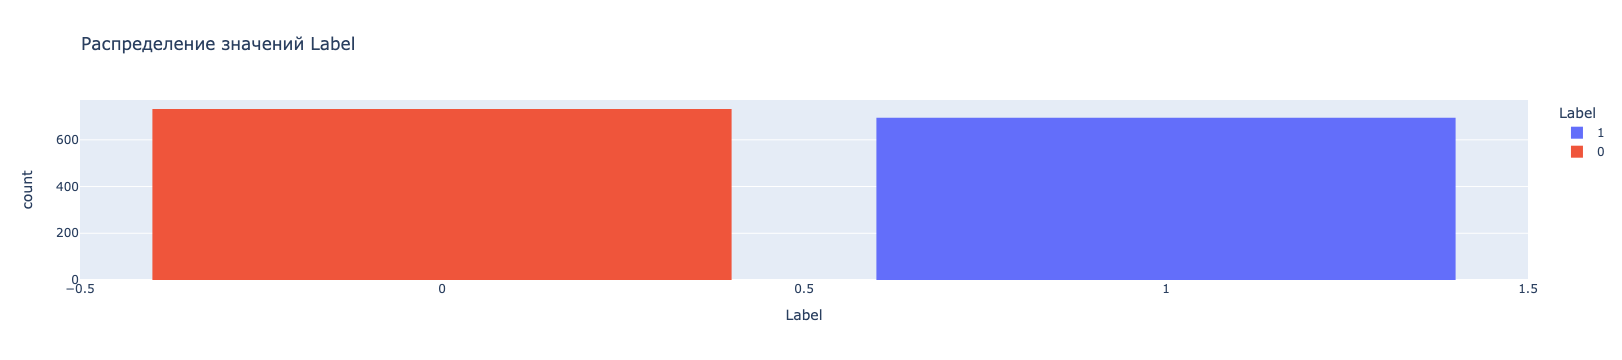

In [125]:
fig = px.histogram(
    df,
    x="Label",
    title="Распределение значений Label",
    labels={"Label": "Label", "count": "Количество"},
    color="Label",
)
fig.update_layout(bargap=0.2)
fig.show()

In [126]:
numeric_cols = df.select(pl.col(pl.NUMERIC_DTYPES)).columns
correlation_matrix = df.select(numeric_cols).corr()

print(correlation_matrix)

shape: (17, 17)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Packet_Le ┆ Duration  ┆ Source_Po ┆ Destinati ┆ … ┆ Sub_Flow_ ┆ Sub_Flow_ ┆ Inbound   ┆ Label    │
│ ngth      ┆ ---       ┆ rt        ┆ on_Port   ┆   ┆ Fwd_Bytes ┆ Bwd_Bytes ┆ ---       ┆ ---      │
│ ---       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64      │
│ f64       ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ -0.006699 ┆ 0.042565  ┆ -0.03302  ┆ … ┆ -0.050409 ┆ 0.031131  ┆ 0.044502  ┆ -0.02183 │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 1        │
│ -0.006699 ┆ 1.0       ┆ -0.001533 ┆ 0.005964  ┆ … ┆ -0.011635 ┆ 0.010935  ┆ 0.078485  ┆ 0.011345 │
│ 0.042565  ┆ -0.001533 ┆ 1.0       ┆ -0.026245 ┆ … ┆ -0.008852 ┆ -0.013124

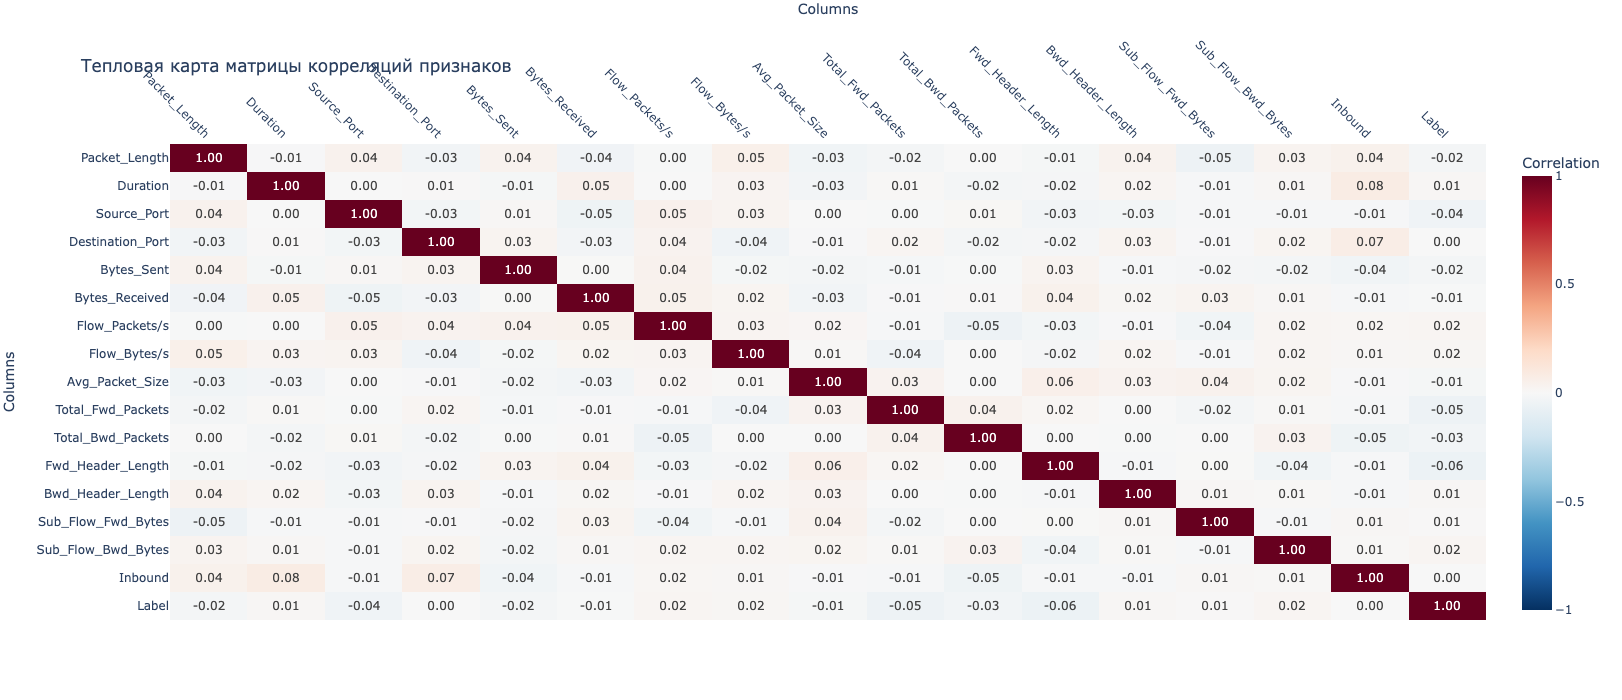

In [127]:
cols = correlation_matrix.columns

fig = px.imshow(
    correlation_matrix,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    range_color=[-1, 1],
    labels=dict(color="Correlation", x="Columns", y="Columns"),
    x=cols,
    y=cols,
    title="Тепловая карта матрицы корреляций признаков"
)

fig.update_xaxes(side="top")
fig.update_layout(height=700, width=800)
fig.update_xaxes(tickangle=45)

fig.show()

In [128]:
target_col = "Label"

numeric_cols = [c for c in df.select(pl.col(pl.NUMERIC_DTYPES)).columns if c != target_col]
df_num = df.select([target_col] + numeric_cols)

corrs = {}
for col in numeric_cols:
    corr, pval = pointbiserialr(df_num[target_col], df_num[col])
    corrs[col] = corr

corr_series = pl.DataFrame({
    "feature": list(corrs.keys()),
    "point_biserial_corr": list(corrs.values())
}).sort("point_biserial_corr", descending=True)

corr_series

feature,point_biserial_corr
str,f64
"""Sub_Flow_Bwd_Bytes""",0.020941
"""Flow_Packets/s""",0.020332
"""Flow_Bytes/s""",0.016045
"""Bwd_Header_Length""",0.011486
"""Duration""",0.011345
…,…
"""Bytes_Sent""",-0.023047
"""Total_Bwd_Packets""",-0.033787
"""Source_Port""",-0.041592


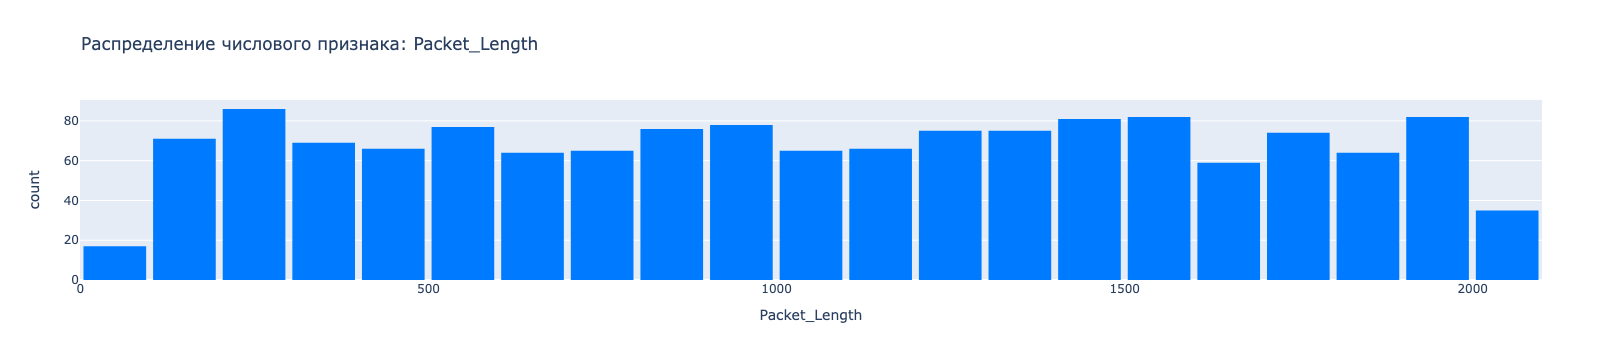

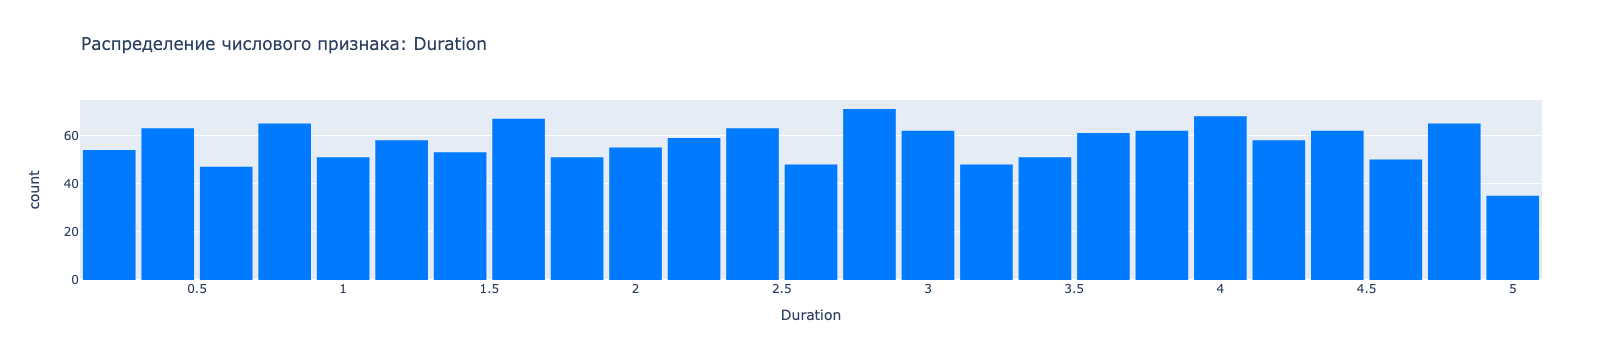

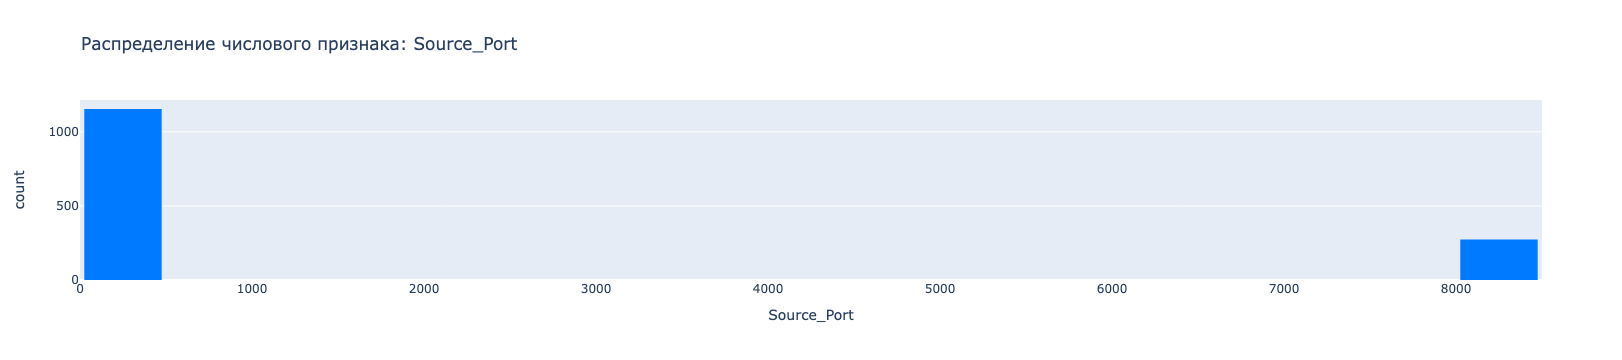

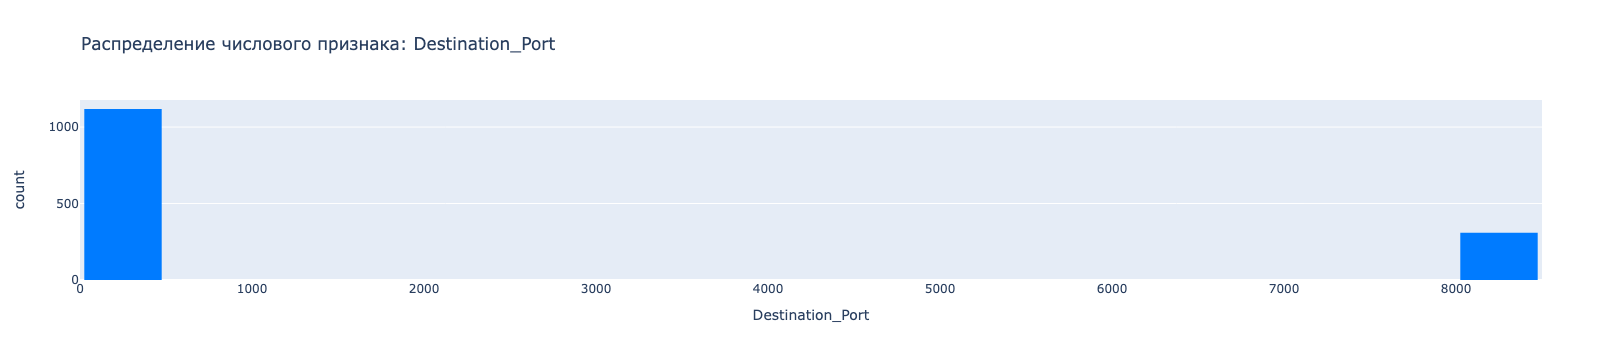

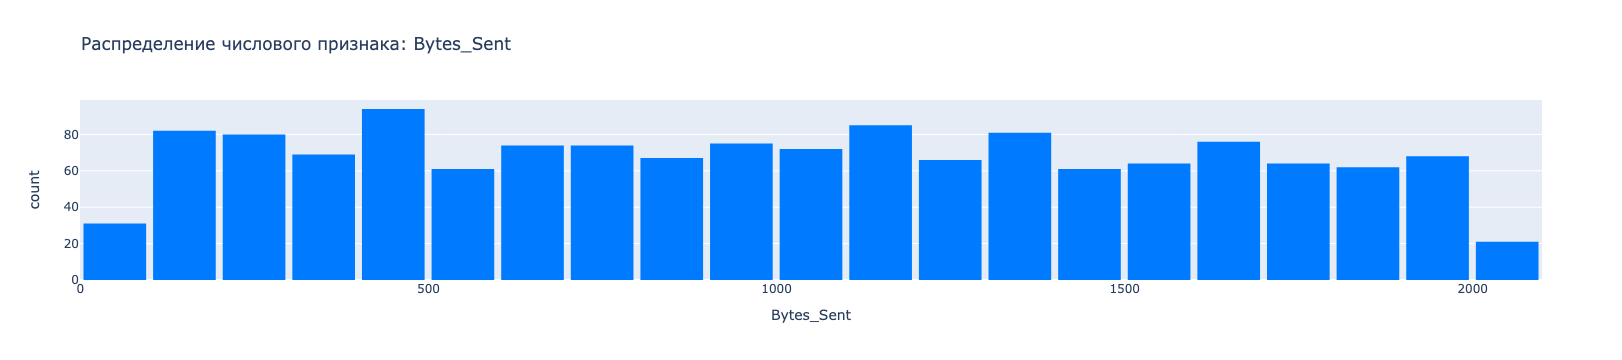

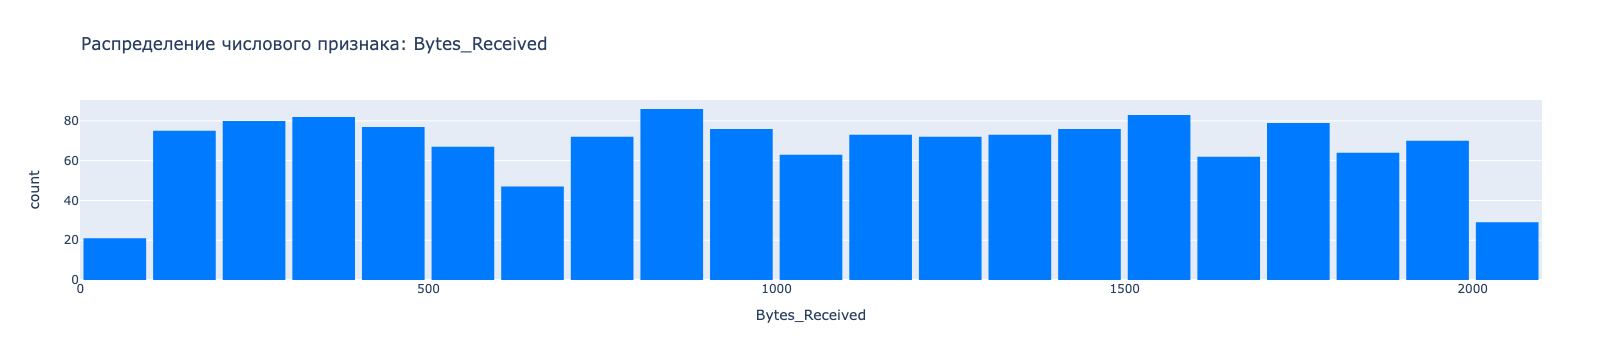

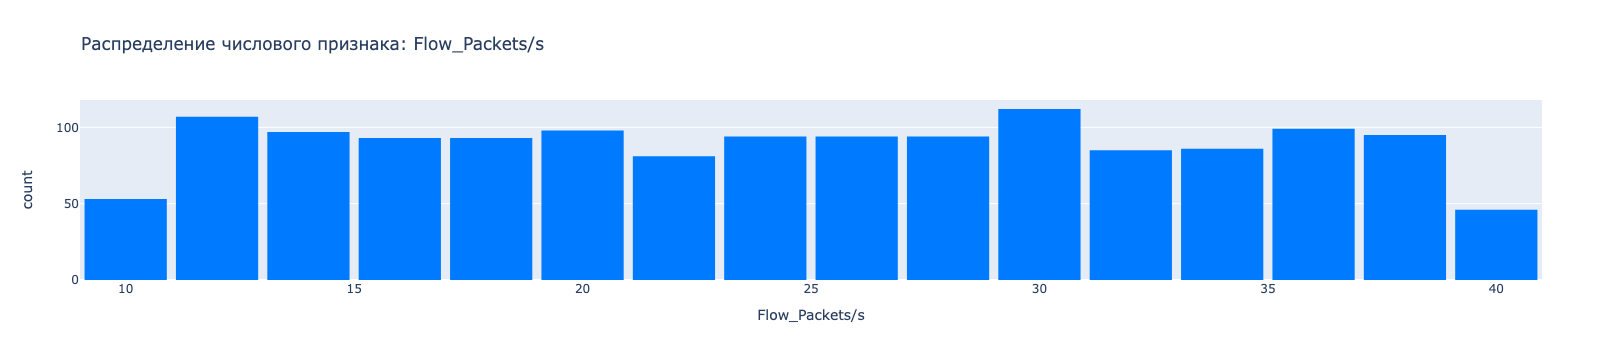

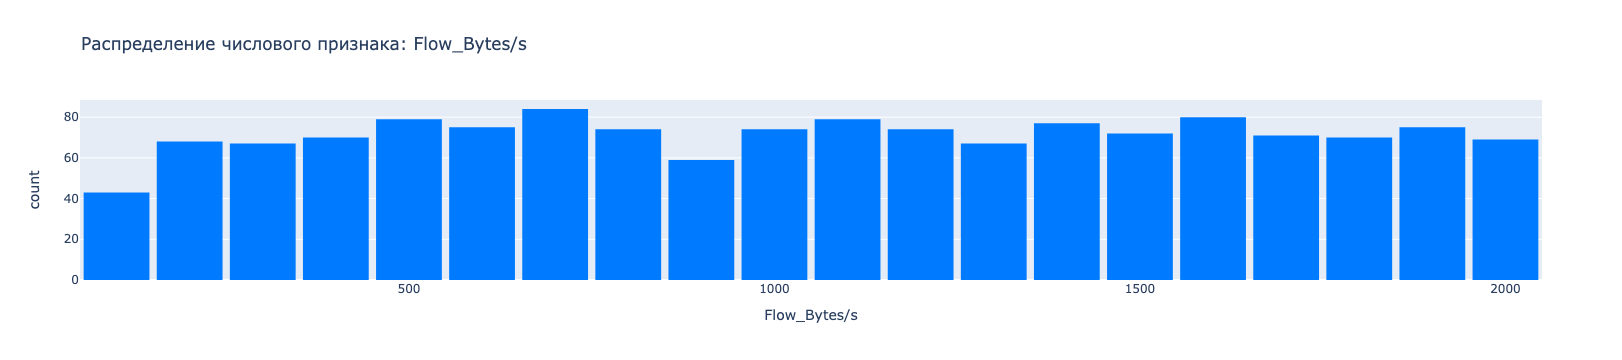

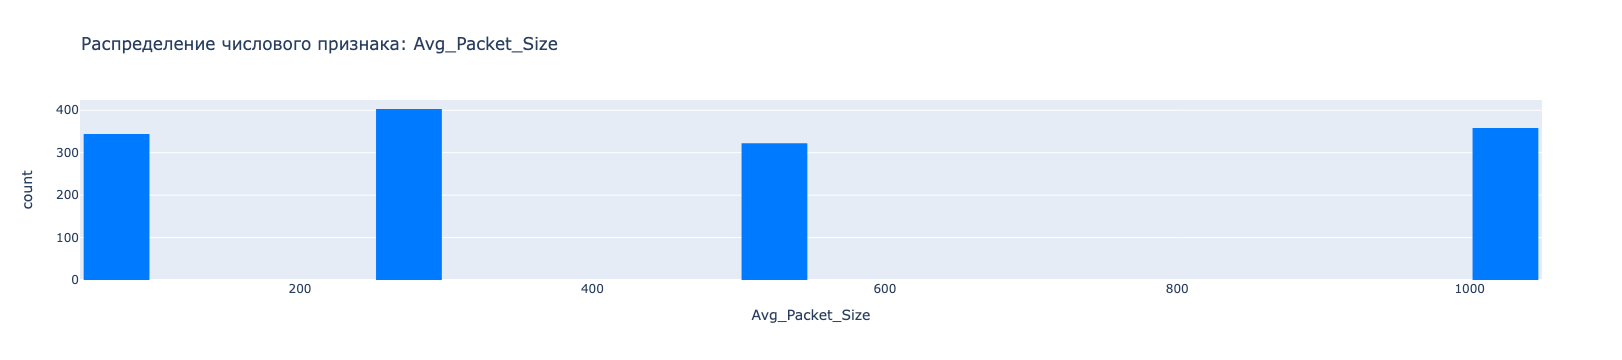

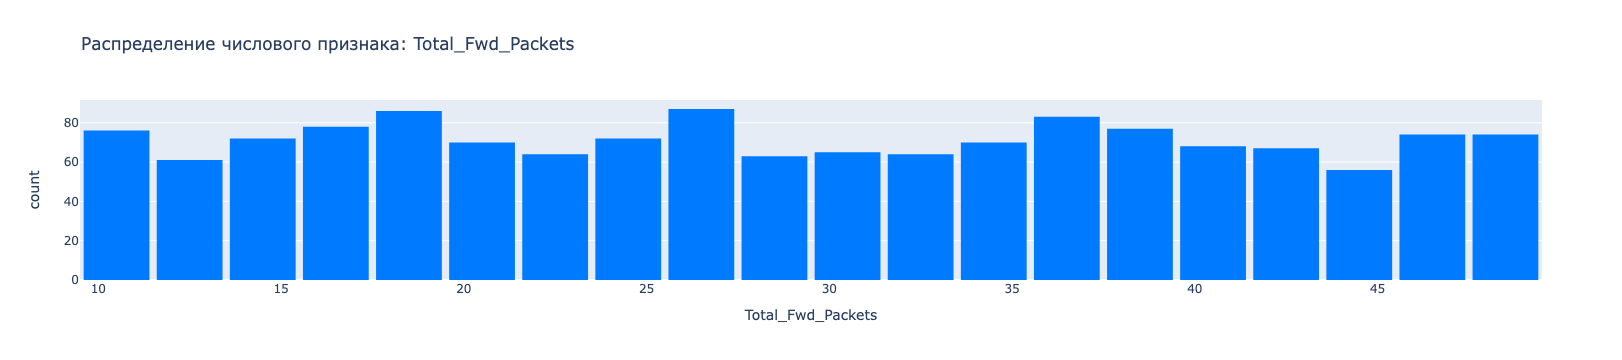

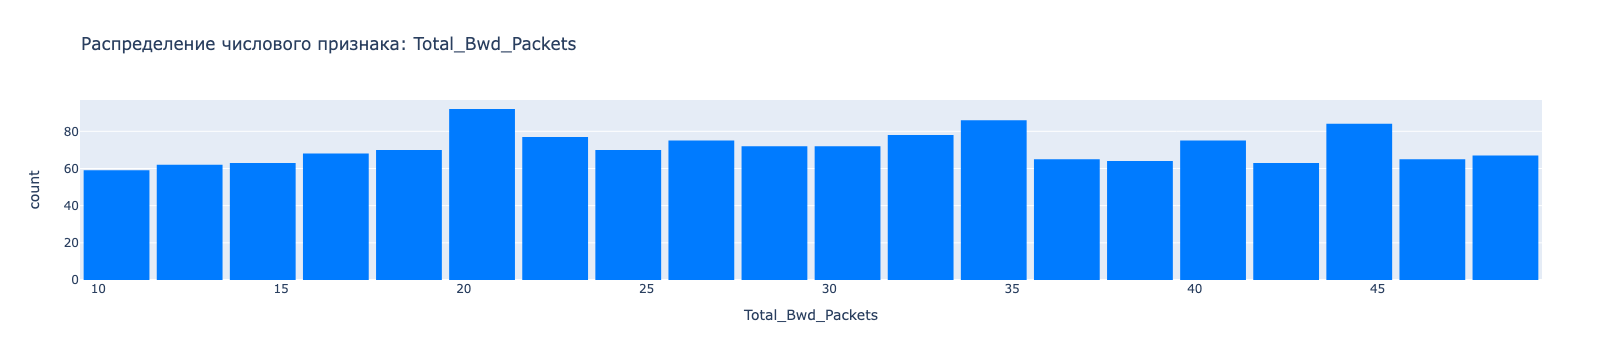

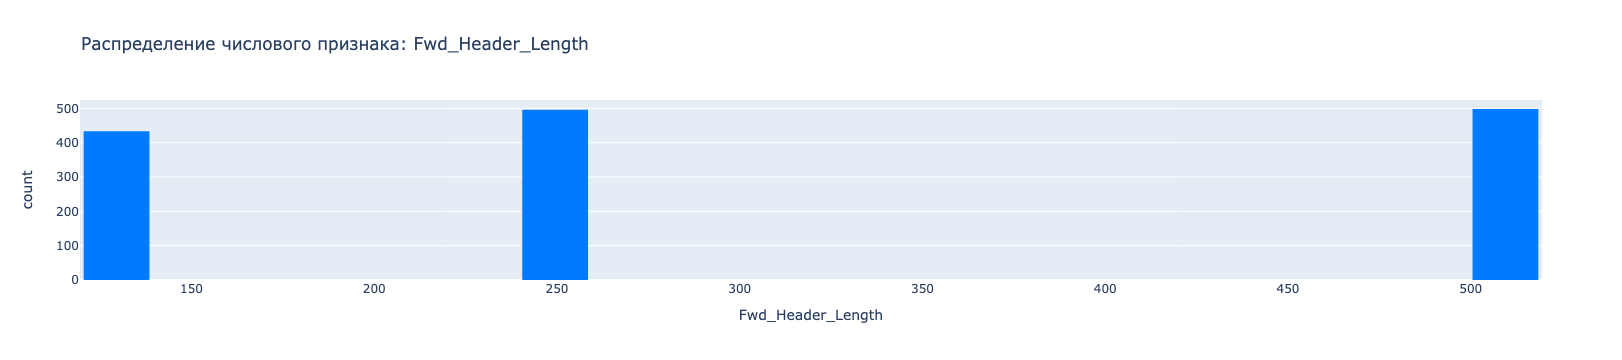

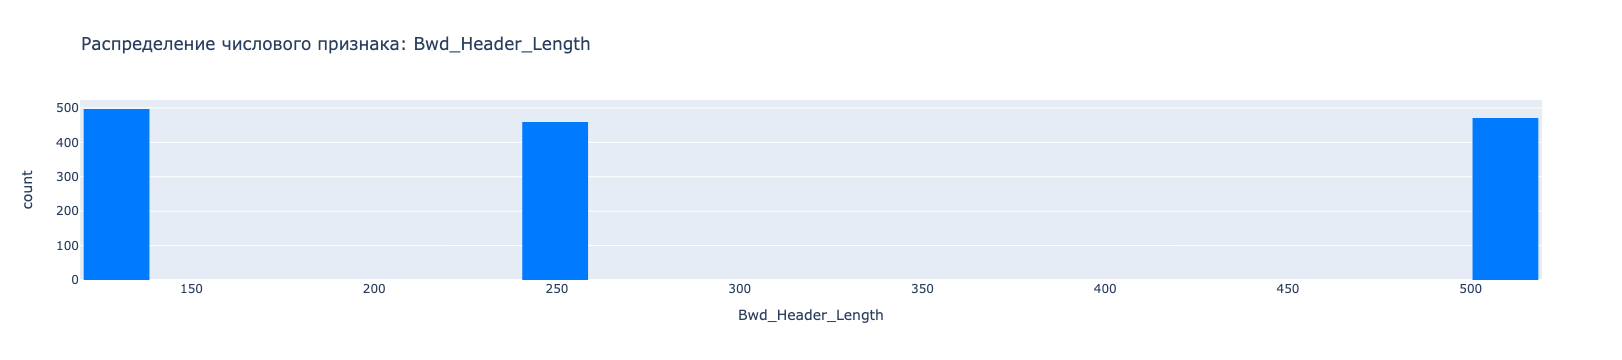

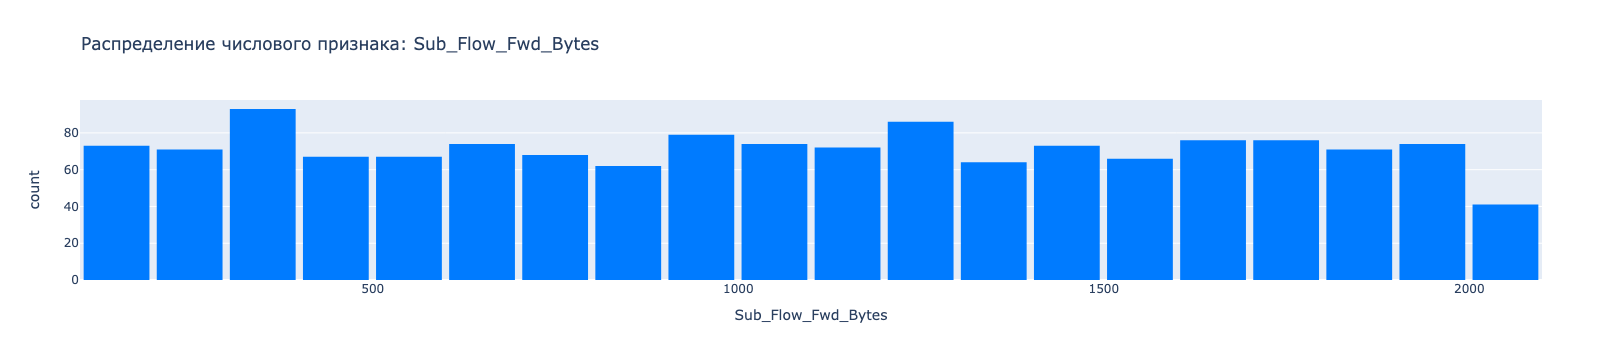

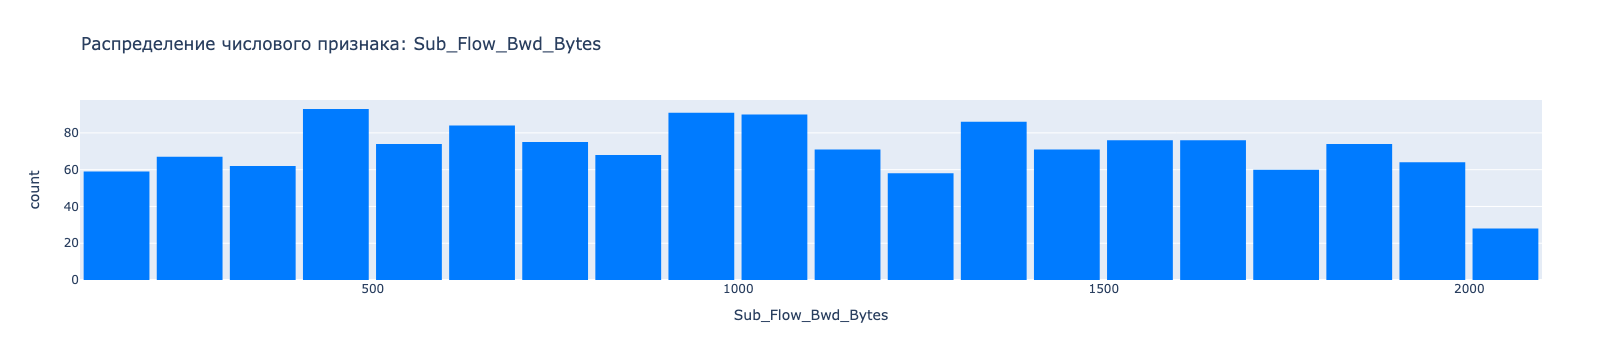

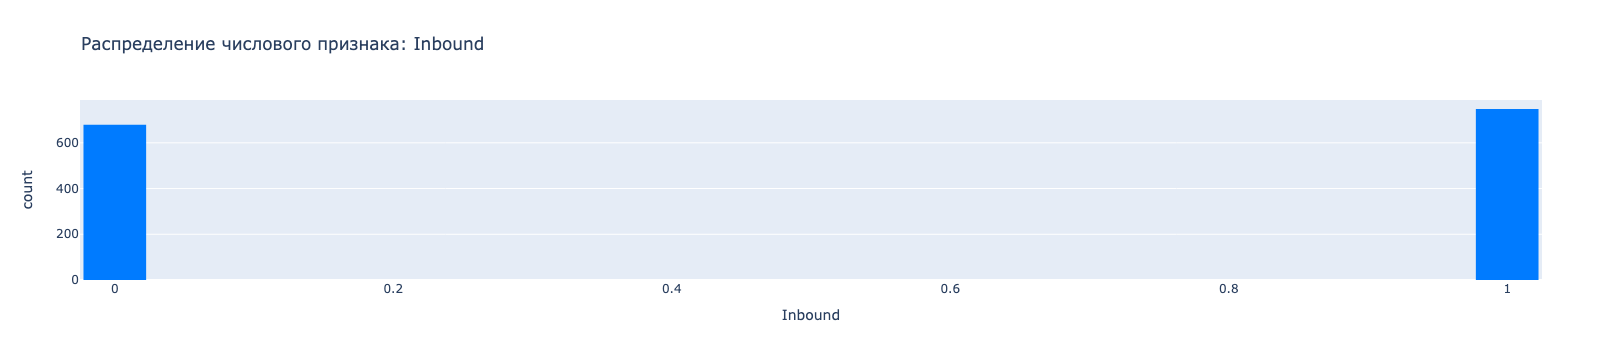

In [129]:
cat_cols = [c for c in df.columns if c not in numeric_cols]

for col in numeric_cols:
    fig = px.histogram(
        df,
        x=col,
        nbins=30,
        title=f"Распределение числового признака: {col}",
        labels={col: col, "count": "Количество"},
        color_discrete_sequence=["#007bff"]
    )
    fig.update_layout(bargap=0.1)
    fig.show()

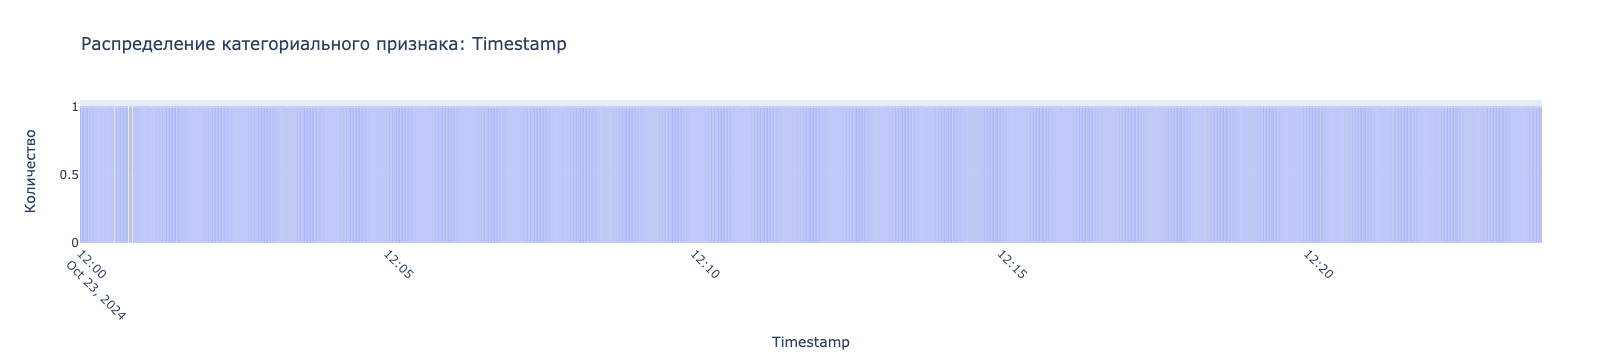

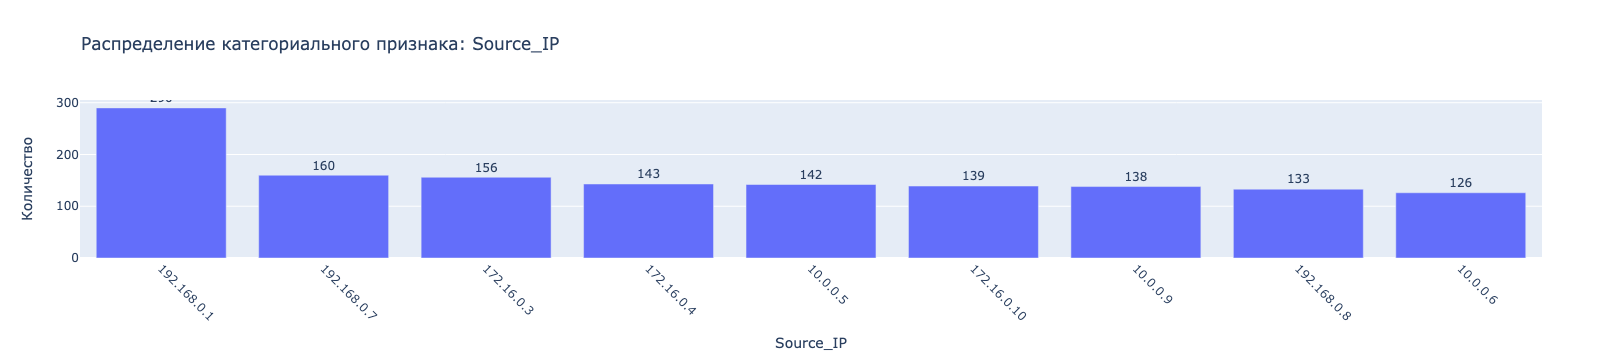

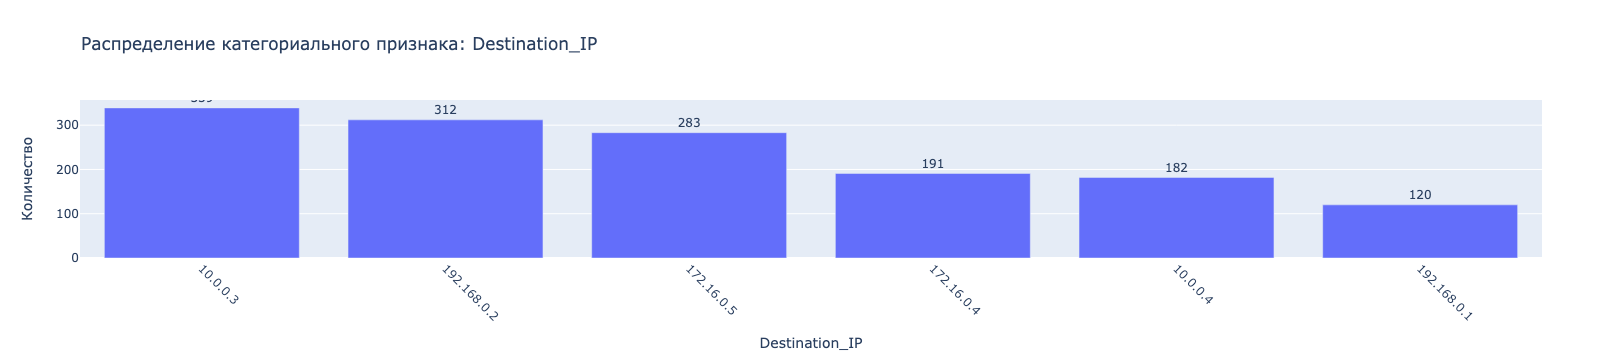

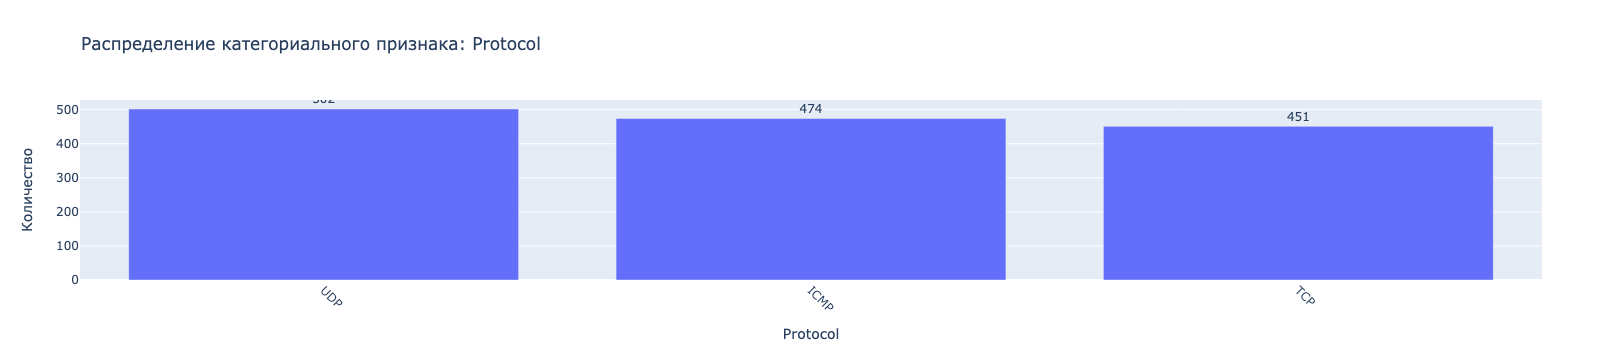

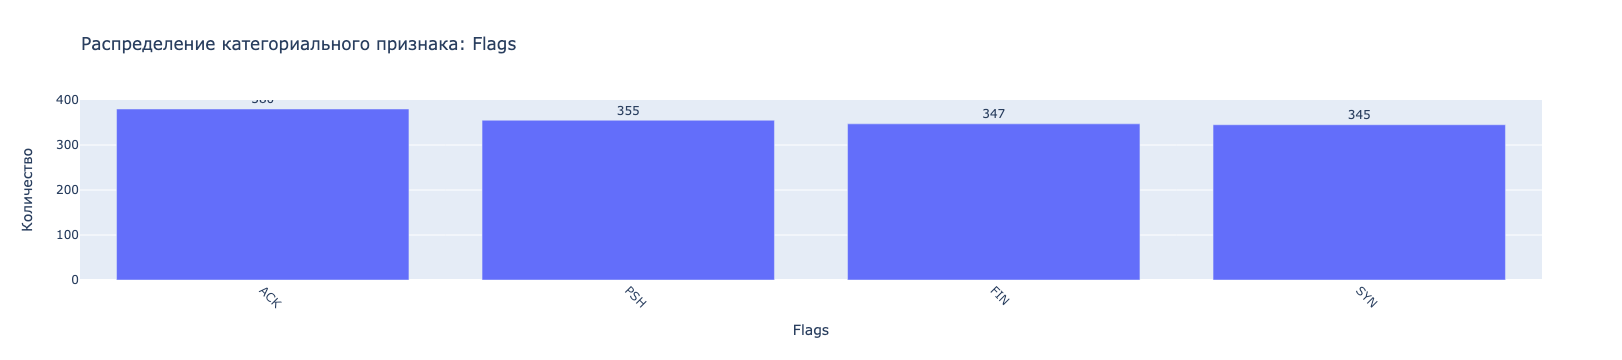

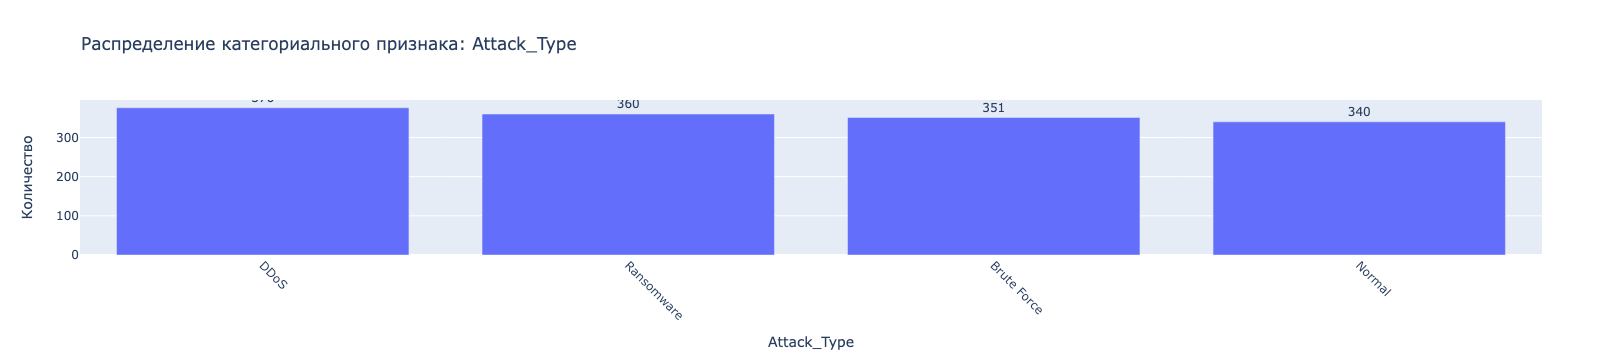

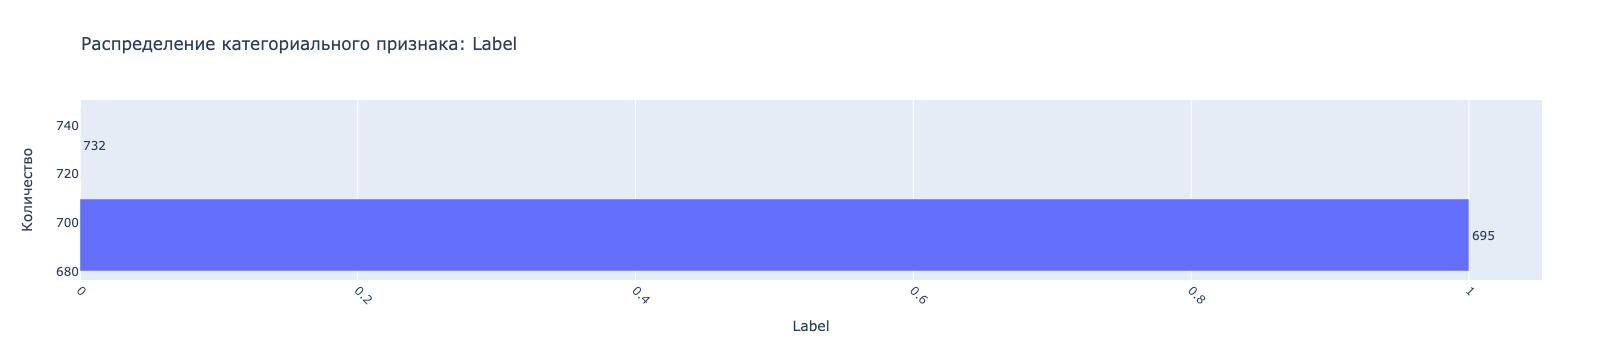

In [130]:
for col in cat_cols:
    vc = (
        df.group_by(col)
          .agg(pl.count().alias("counts"))
          .sort("counts", descending=True)
    )
    fig = px.bar(
        vc,
        x=col,
        y="counts",
        text="counts",
        title=f"Распределение категориального признака: {col}",
        labels={col: col, "counts": "Количество"},
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(xaxis_tickangle=45)
    fig.show()

In [131]:
df = df.drop('Timestamp')

df

Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64
"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1,"""DDoS""",1
"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1,"""DDoS""",1
"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0,"""DDoS""",1
"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0,"""Ransomware""",0
"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1,"""Normal""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1,"""Ransomware""",1
"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1,"""Normal""",1
"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1,"""Normal""",1


In [133]:
target_col = "Label"

numeric_cols = [c for c in df.select(pl.col(pl.NUMERIC_DTYPES)).columns if c != target_col]
df_num = df.select([target_col] + numeric_cols)

corrs = {}
for col in numeric_cols:
    corr, pval = pointbiserialr(df_num[target_col], df_num[col])
    corrs[col] = corr

corr_series = pl.DataFrame({
    "feature": list(corrs.keys()),
    "point_biserial_corr": list(corrs.values())
}).sort("point_biserial_corr", descending=True)

corr_series

feature,point_biserial_corr
str,f64
"""Sub_Flow_Bwd_Bytes""",0.020941
"""Flow_Packets/s""",0.020332
"""Flow_Bytes/s""",0.016045
"""Bwd_Header_Length""",0.011486
"""Duration""",0.011345
…,…
"""Bytes_Sent""",-0.023047
"""Total_Bwd_Packets""",-0.033787
"""Source_Port""",-0.041592


In [134]:
targets = ['Attack_Type', 'Label']
X = df.drop(targets)
y = df[targets]

In [135]:
X

Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound
str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64
"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1
"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1
"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0
"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0
"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1
"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1
"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1


In [136]:
y

Attack_Type,Label
str,i64
"""DDoS""",1
"""DDoS""",1
"""DDoS""",1
"""Ransomware""",0
"""Normal""",1
…,…
"""Ransomware""",1
"""Normal""",1
"""Normal""",1


In [137]:
numeric_cols = X.select(pl.col(pl.NUMERIC_DTYPES)).columns
cat_cols = [c for c in X.columns if c not in numeric_cols]

X = X.to_pandas()
y = y.to_pandas()

In [138]:
target = 'Label'

X_train, X_test, y_train, y_test = train_test_split(
    X, y[target], test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1141, 20) (1141,)
(286, 20) (286,)


In [139]:
cat_transformer = make_pipeline(TargetEncoder())

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", cat_transformer, cat_cols)
])

In [151]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [152]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)  

In [153]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.54      0.50       147
           1       0.42      0.35      0.38       139

    accuracy                           0.45       286
   macro avg       0.45      0.45      0.44       286
weighted avg       0.45      0.45      0.45       286



In [154]:
!pip install catboost -q


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [155]:
from catboost import Pool, CatBoostClassifier 

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)

In [156]:
model = CatBoostClassifier(task_type="GPU")

model.fit(train_pool, verbose=100)

Learning rate set to 0.033467
0:	learn: 0.6915554	total: 33ms	remaining: 33s
100:	learn: 0.5945536	total: 2.77s	remaining: 24.6s
200:	learn: 0.5286593	total: 5.52s	remaining: 21.9s
300:	learn: 0.4706654	total: 8.17s	remaining: 19s
400:	learn: 0.4204710	total: 10.8s	remaining: 16.2s
500:	learn: 0.3845356	total: 13.5s	remaining: 13.4s
600:	learn: 0.3556092	total: 16.1s	remaining: 10.7s
700:	learn: 0.3284626	total: 18.7s	remaining: 7.96s
800:	learn: 0.3071828	total: 21.2s	remaining: 5.26s
900:	learn: 0.2901726	total: 23.7s	remaining: 2.61s
999:	learn: 0.2755607	total: 26.3s	remaining: 0us


In [157]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [158]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.53      0.50       147
           1       0.44      0.39      0.41       139

    accuracy                           0.46       286
   macro avg       0.46      0.46      0.46       286
weighted avg       0.46      0.46      0.46       286



In [159]:
# На бустинге качество сильно не выросло, а значит дело не в коррелированных фичах / проклятии размерности